In [8]:
# Import Labraries
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
#Load DataSheet 
data_store =pd.read_csv('DataSheet Sales/superstore_final_dataset.csv', encoding='latin1')

In [12]:
data_store.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [10]:
#Understand DataSheet
data_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   str    
 2   Order_Date     9800 non-null   str    
 3   Ship_Date      9800 non-null   str    
 4   Ship_Mode      9800 non-null   str    
 5   Customer_ID    9800 non-null   str    
 6   Customer_Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product_ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub_Category   9800 non-null   str    
 16  Product_Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [13]:
# Data Cleaning

In [15]:
data_store.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [16]:
data_store = data_store.dropna()

In [17]:
data_store = data_store.drop_duplicates()

In [18]:
# KPI Calculations

In [24]:
# Revenue

total_revenue = data_store['Sales'].sum()
print('Total Revenue Is :-', total_revenue)

Total Revenue Is :- 2252607.4127


In [28]:
total_order = data_store['Order_ID'].nunique()
print("Total Order Is :-", total_order)

Total Order Is :- 4916


In [29]:
# Average Order Value

avg_order_value = total_revenue / total_order
print("Average Order Value Is :-", avg_order_value)

Average Order Value Is :- 458.2195713384866


In [27]:
print(data_store.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='str')


In [30]:
# Profit Mergin
reason = ("Profit Margin could not be calculated because the dataset does not contain a Profit column or cost-related information.")
print("Profit Margin", reason)

Profit Margin Profit Margin could not be calculated because the dataset does not contain a Profit column or cost-related information.


In [31]:
# Conversion Metrics
reason_2 = ("Not calculated because the dataset contains completed sales transactions only and does not include visitor or lead data required for conversion analysis.")
print("Conversion Metrics", reason_2)

Conversion Metrics Not calculated because the dataset contains completed sales transactions only and does not include visitor or lead data required for conversion analysis.


In [32]:
# Sales By Region

In [35]:
region_sales = data_store.groupby('Region')['Sales'].sum()
print( region_sales)

Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


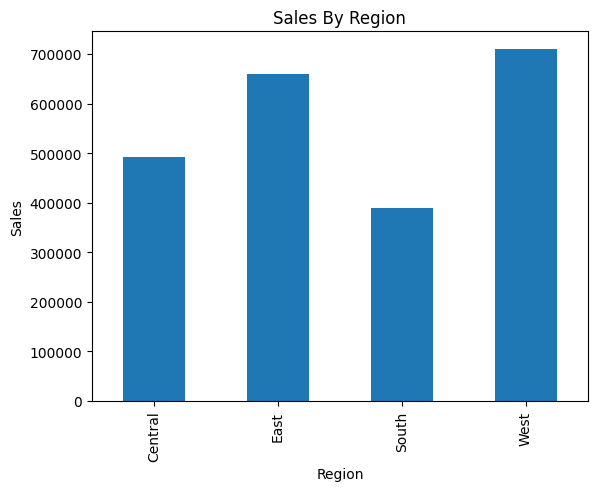

In [38]:
region_sales.plot(kind='bar')
plt.title("Sales By Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

In [40]:
# Sales By Category

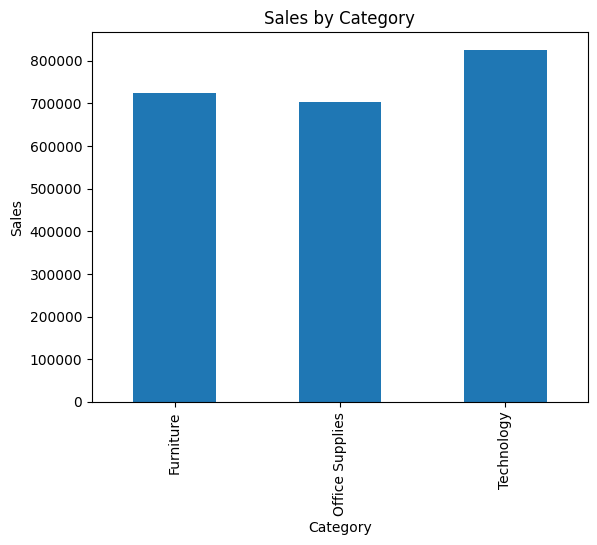

In [43]:
category_sales = data_store.groupby('Category')['Sales'].sum()
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

In [44]:
# Top Products

In [50]:
top_product = data_store.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("Top Product Is :-", top_product)

Top Product Is :- Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


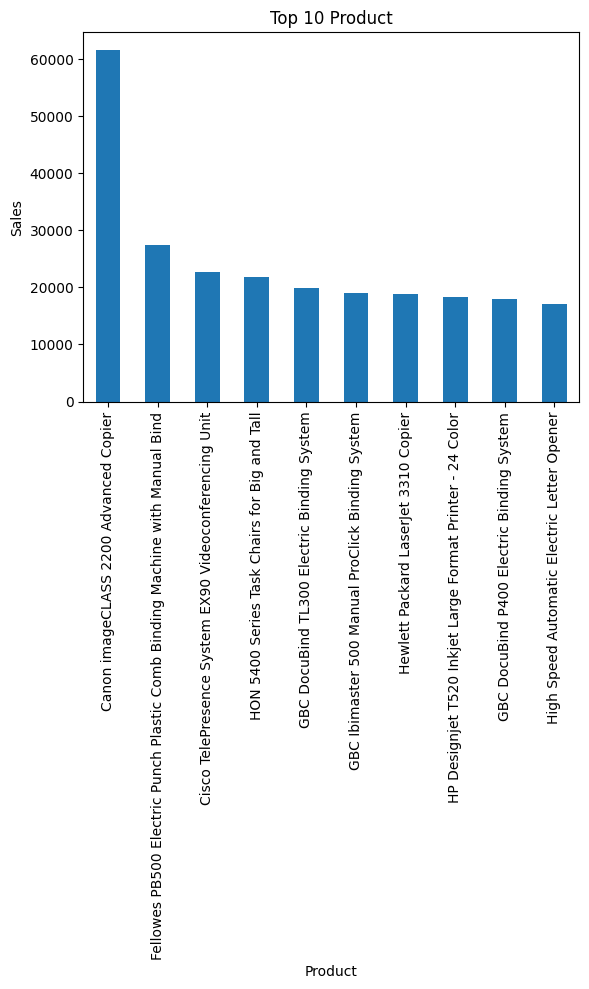

In [56]:
top_product.plot(kind='bar')
plt.title("Top 10 Product")
plt.xlabel('Product')
plt.ylabel('Sales')
plt.show()

In [58]:
# Worst Product

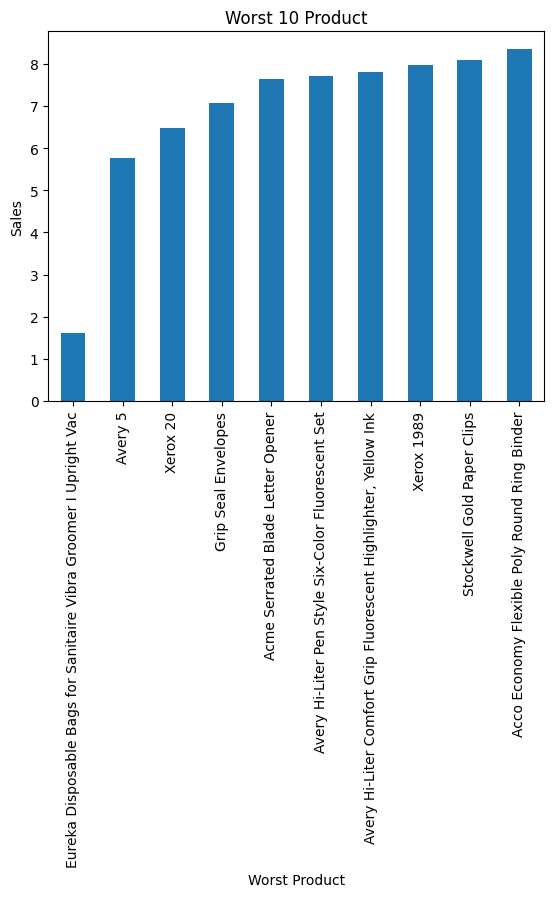

Worst Product Is :- Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
Stockwell Gold Paper Clips                                          8.096
Acco Economy Flexible Poly Round Ring Binder                        8.352
Name: Sales, dtype: float64


In [62]:
worst_product = data_store.groupby('Product_Name')['Sales'].sum().sort_values().head(10)
worst_product.plot(kind='bar')
plt.title('Worst 10 Product')
plt.xlabel("Worst Product")
plt.ylabel("Sales")
plt.show()
print("Worst Product Is :-",worst_product)

In [63]:
# Seasonality

In [68]:
data_store['Order_Date'].head(10)

0     8/11/2017
1     8/11/2017
2     12/6/2017
3    11/10/2016
4    11/10/2016
5      9/6/2015
6      9/6/2015
7      9/6/2015
8      9/6/2015
9      9/6/2015
Name: Order_Date, dtype: str

In [69]:
data_store['Order_Date'] = pd.to_datetime(data_store['Order_Date'], dayfirst=True)
data_store['Month'] = data_store['Order_Date'].dt.month

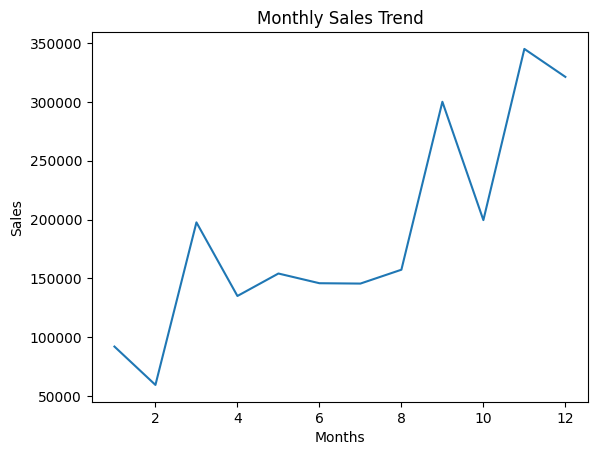

In [73]:
monthly_sales = data_store.groupby('Month')["Sales"].sum()
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()